# Sesi 08 - Exploratory Data Analytics

EDA atau Exploratory Data Analytics adalah proses memahami data secara mendalam sebelum membuat model atau laporan
Kita akan pakai dataset Superstore yang sudah kita kenal di Sesi 06

## 1. Load data & persiapan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("samplesuperstore.csv", encoding = "latin1")
print(df)

       Row ID        Order ID  Order Date  Ship Date       Ship Mode  \
0           1  US-2023-103800    1/3/2023   1/7/2023  Standard Class   
1           2  US-2023-112326    1/4/2023   1/8/2023  Standard Class   
2           3  US-2023-112326    1/4/2023   1/8/2023  Standard Class   
3           4  US-2023-112326    1/4/2023   1/8/2023  Standard Class   
4           5  US-2023-141817    1/5/2023  1/12/2023  Standard Class   
...       ...             ...         ...        ...             ...   
10189   10190  US-2026-143259  12/30/2026   1/3/2027  Standard Class   
10190   10191  US-2026-115427  12/30/2026   1/3/2027  Standard Class   
10191   10192  US-2026-156720  12/30/2026   1/3/2027  Standard Class   
10192   10193  US-2026-143259  12/30/2026   1/3/2027  Standard Class   
10193   10194  CA-2026-143500  12/30/2026   1/3/2027  Standard Class   

      Customer ID      Customer Name      Segment Country/Region  \
0        DP-13000      Darren Powers     Consumer  United States   

In [9]:
# Konversi kolom tanggal
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [11]:
# Tambah kolom tahun & tahun
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

print("Shape: ", df.shape)
print("\n5 baris pertama:")
df.head()

Shape:  (10194, 23)

5 baris pertama:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,1
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,1
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023,1
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,1
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,1


## 2. Distribusi Sales & Profit

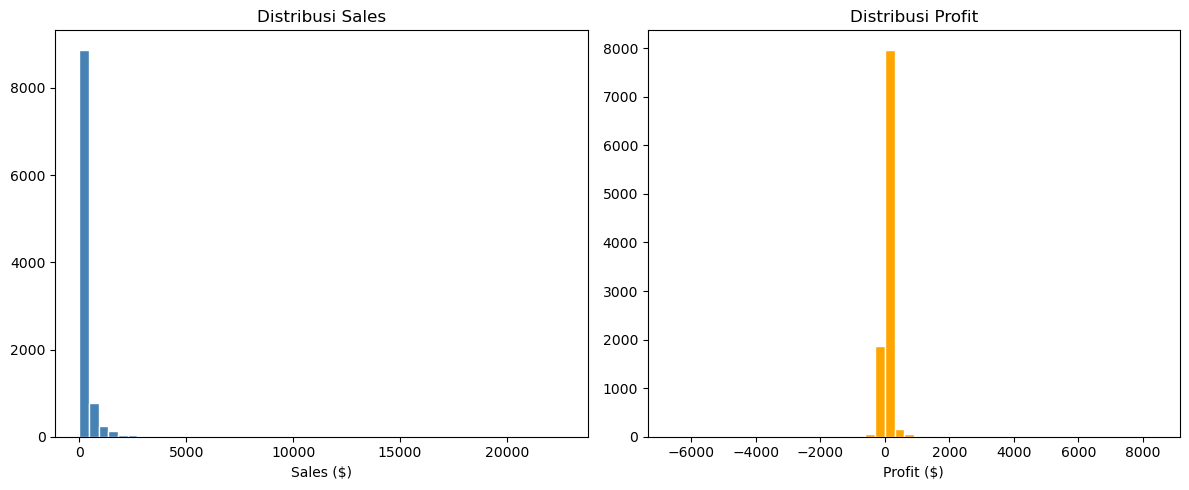

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(df["Sales"], bins=50, color="steelblue", edgecolor="white")
ax1.set_title("Distribusi Sales")
ax1.set_xlabel("Sales ($)")

ax2.hist(df["Profit"], bins=50, color="orange", edgecolor="white")
ax2.set_title("Distribusi Profit")
ax2.set_xlabel("Profit ($)")

plt.tight_layout()
plt.show()

## 3. Tren Penjualan per Tahun dan per Bulan

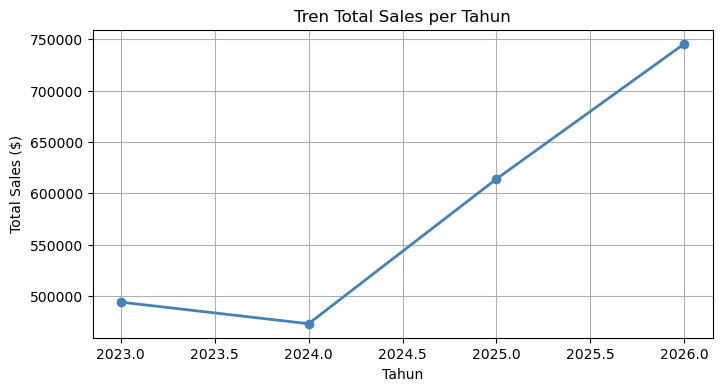

Year
2023    494040.2121
2024    472993.0310
2025    613933.5800
2026    745567.5312
Name: Sales, dtype: float64


In [15]:
# Sales per Tahun

per_tahun = df.groupby("Year")["Sales"].sum()

plt.figure(figsize=(8,4))
plt.plot(per_tahun.index, per_tahun.values, marker="o", color="steelblue", linewidth=2)
plt.title("Tren Total Sales per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Total Sales ($)")
plt.grid(True)
plt.show()

print(per_tahun)

## 4. Korelasi antar variabel

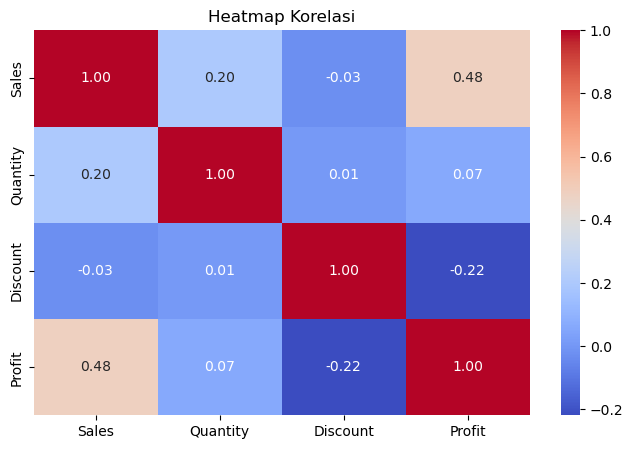

In [17]:
# Heatmap korelasi
plt.figure(figsize=(8, 5))
korelasi = df[["Sales", "Quantity", "Discount", "Profit"]].corr()
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap Korelasi")
plt.show()

## 5. Profit vs Discount

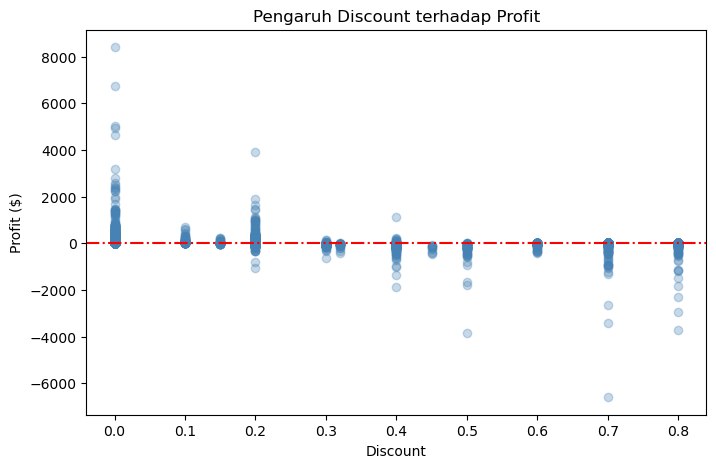

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.3, color="steelblue")
plt.title("Pengaruh Discount terhadap Profit")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.axhline(y=0, color="red", linestyle="-.")
plt.show()

## 6. Kesimpulan EDA

In [35]:
print("=" *50)
print("   HASIL EDA - SUPERSTORE DATASET")
print("=" *50)

print("\nTREN:")
print(f" Sales tertinggi: Tahun {per_tahun.idxmax()} (${per_tahun.max():,.0f})")
print(f" Sales terendah: Tahun {per_tahun.idxmin()} (${per_tahun.min():,.0f})")

print("\nPROFIT:")
print(f" Rata-rata profit per Transaksi: ${df['Profit'].mean():,.2f}")
print(f" Transaksi rugi: {(df['Profit'] < 0).sum()} dari {len(df)} ({(df['Profit'] < 0).mean()*100:.1f}%)")

print("\nINSIGHT UTAMA:")
print("  - Sales terus naik tiap tahun")
print("  - Diskon > 40% hampir selalu rugi")
print("  - 1 dari 3 transaksi menghasilkan profit negatif")
print("  - Perlu evaluasi kebijakan diskon!")
print("=" * 50)

   HASIL EDA - SUPERSTORE DATASET

TREN:
 Sales tertinggi: Tahun 2026 ($745,568)
 Sales terendah: Tahun 2024 ($472,993)

PROFIT:
 Rata-rata profit per Transaksi: $28.67
 Transaksi rugi: 1901 dari 10194 (18.6%)

INSIGHT UTAMA:
  - Sales terus naik tiap tahun
  - Diskon > 40% hampir selalu rugi
  - 1 dari 3 transaksi menghasilkan profit negatif
  - Perlu evaluasi kebijakan diskon!
